<a href="https://colab.research.google.com/github/shio0418/ML_exercise/blob/main/ml2024_02_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 演習2: 重回帰

以下の`X`を説明変数、`Y`を目的変数として3次の多項式にフィッティングすることを考える。NumPy, SciPy, scikit-learn, statsmodel等のライブラリには回帰分析を行う便利な関数として以下のようなものがあるが、ここでは使わずに講義中で説明した行列演算をプログラムとして表現すること。

+ [np.polyfit](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html), [np.polynomial.polynomial.Polynomial.fit](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html#numpy.polynomial.polynomial.Polynomial.fit)
+ [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html), [scipy.optimize.curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), [scipy.stats.linregress](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)
+ [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
+ [statsmodels.regression.linear_model.OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html#statsmodels.regression.linear_model.OLS)


In [ ]:
import numpy as np

X = np.array([ 0.  ,  0.16,  0.22,  0.34,  0.44,  0.5 ,  0.67,  0.73,  0.9 ,  1.  ])
Y = np.array([-0.06,  0.94,  0.97,  0.85,  0.25,  0.09, -0.9 , -0.93, -0.53,  0.08])

## 1. 行列演算による3次関数のパラメータ推定

$\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3$とおき、重回帰により平均二乗残差を最小にする$\boldsymbol{w} = \begin{pmatrix}
w_0 \\
w_1 \\
w_2 \\
w_3
\end{pmatrix}$を行列演算により求めよ。
<!-- 03:01 -->

In [ ]:
#式2.25を利用する
ones_vec = np.ones(X.size)
X_matrix = np.column_stack((ones_vec, X,X**2,X**3))

w = np.linalg.pinv(X_matrix.T @ X_matrix) @ X_matrix.T @ Y
w

array([ -0.06314113,  10.97825774, -32.58352732,  21.81795457])

## 2. 回帰曲線の描画

回帰で求めた3次関数をデータ点とともにグラフに描け。
<!-- 03:02 -->

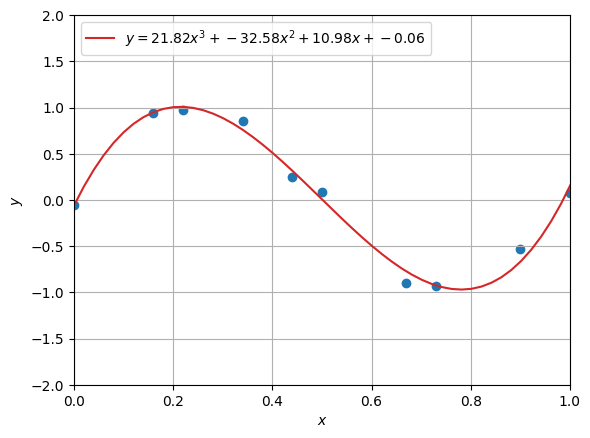

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
D = np.column_stack((X,Y))
ax.scatter(D[:,0], D[:,1], marker='o')

x = np.linspace(0, 10, 500)
ax.plot(x, w[3] * x ** 3 + w[2] * x ** 2 + w[1] * x + w[0], 'tab:red', ls='-', label=(\
    f'$y = {w[3]:.2f} x^3 + {w[2]:.2f} x^2 + {w[1]:.2f} x + {w[0]:.2f}$'))
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(0, 1.0)
ax.set_ylim(-2, 2)
ax.grid()
plt.legend(loc='upper left')
plt.show()

## 3. 残差の計算

各事例$(x_i, y_i)$に対して残差$\hat{\epsilon}_i$を求めよ。
<!-- 03:03 -->

In [ ]:
eps = Y - X_matrix @ w
eps

array([ 0.00314113, -0.00860815, -0.03735043,  0.08965637, -0.06766203,
        0.08264976, -0.12757962, -0.00478055,  0.1400774 , -0.06954387])

## 4. 説明変数と残差の共分散

説明変数と残差の共分散を求めよ。
<!-- 03:04 -->

In [ ]:
np.cov(X_matrix.T,eps)[0][1]

0.0

## 5. 目的変数の推定値と残差の共分散

目的変数の推定値と残差の共分散を求めよ。
<!-- 03:05 -->

In [ ]:
Y_hat = X_matrix @ w
np.cov(Y_hat,eps)[0][1]

-2.6206563308466276e-14

In [ ]:
e_vec = Y - regression_curve(X)
print(np.cov(regression_curve(X), e_vec)[0,1])